# Inspect .laz files from `datasource/`

Quick look at three point clouds:
- `07-15-MS.laz` (multispectral)
- `2025-07-15-IR.laz` (infrared)
- `07-15-LIDAR.laz` (LiDAR)

For each file we log: header info, available dimensions, basic XYZ stats, a sample of the DataFrame, a 2D scatter (XY colored by Z) and a histogram of Z. Run all cells (`Kernel ▸ Restart & Run All`).

In [14]:
import os
from pathlib import Path

import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASOURCE = Path('/home/luka/Coding/DIPLOMSKI-RAD/datasource')
FILES = [
    DATASOURCE / '07-15-MS.laz',
    DATASOURCE / '2025-07-15-IR.laz',
    DATASOURCE / '4VOLCALC.las',
  #  DATASOURCE / '07-15-LIDAR.laz',
]

# Subsample for plotting if files are large
MAX_PLOT_POINTS = 200_000

In [15]:
def load_las_to_df(path: Path) -> tuple[laspy.LasData, pd.DataFrame]:
    las = laspy.read(str(path))
    data = {'X': np.asarray(las.x), 'Y': np.asarray(las.y), 'Z': np.asarray(las.z)}
    for dim in las.point_format.dimension_names:
        if dim in ('X', 'Y', 'Z'):
            continue
        try:
            data[dim] = np.asarray(getattr(las, dim))
        except Exception:
            pass
    return las, pd.DataFrame(data)


def log_header(path: Path, las: laspy.LasData, df: pd.DataFrame) -> None:
    h = las.header
    size_mb = path.stat().st_size / 1024 / 1024
    print('=' * 72)
    print(f'File:           {path.name}  ({size_mb:.1f} MB)')
    print(f'Point count:    {h.point_count:,}')
    print(f'Point format:   {h.point_format.id}  (LAS {h.version})')
    print(f'Scales:         {h.scales}')
    print(f'Offsets:        {h.offsets}')
    print(f'Mins:           {h.mins}')
    print(f'Maxs:           {h.maxs}')
    print(f'CRS:            {las.header.parse_crs() if hasattr(las.header, "parse_crs") else "n/a"}')
    print(f'Dimensions ({len(df.columns)}): {list(df.columns)}')
    print('\nXYZ stats:')
    print(df[['X', 'Y', 'Z']].describe().round(3))
    print('\nHead:')
    print(df.head())


def plot_cloud(name: str, df: pd.DataFrame) -> None:
    n = len(df)
    if n > MAX_PLOT_POINTS:
        idx = np.random.default_rng(0).choice(n, MAX_PLOT_POINTS, replace=False)
        d = df.iloc[idx]
    else:
        d = df

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sc = axes[0].scatter(d['X'], d['Y'], c=d['Z'], s=0.4, cmap='viridis')
    axes[0].set_aspect('equal')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_title(f'{name} — XY colored by Z (n={len(d):,}/{n:,})')
    fig.colorbar(sc, ax=axes[0], label='Z')

    axes[1].hist(df['Z'], bins=80, color='steelblue', edgecolor='black')
    axes[1].set_xlabel('Z')
    axes[1].set_ylabel('count')
    axes[1].set_title('Z distribution')

    plt.tight_layout()
    plt.show()


def inspect(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f'MISSING: {path}')
        return pd.DataFrame()
    las, df = load_las_to_df(path)
    log_header(path, las, df)
    plot_cloud(path.name, df)
    return df

## 07-15-MS.laz (multispectral)

File:           07-15-MS.laz  (389.2 MB)
Point count:    30,362,701
Point format:   8  (LAS 1.4)
Scales:         [1.e-08 1.e-08 1.e-03]
Offsets:        [13.61 45.27 30.  ]
Mins:           [13.6139292  45.27115081 35.734     ]
Maxs:           [13.6154564  45.27275984 45.485     ]
CRS:            GEOGCS["WGS 84",DATUM["World Geodetic System 1984 ensemble",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],TOWGS84[0,0,0,0,0,0,0],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.01745329251994328,AUTHORITY["EPSG","9102"]],AUTHORITY["EPSG","4326"]]
Dimensions (26): ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'confidence', 'normal x', 'normal y', 'normal z']

XYZ stats:
                  X          

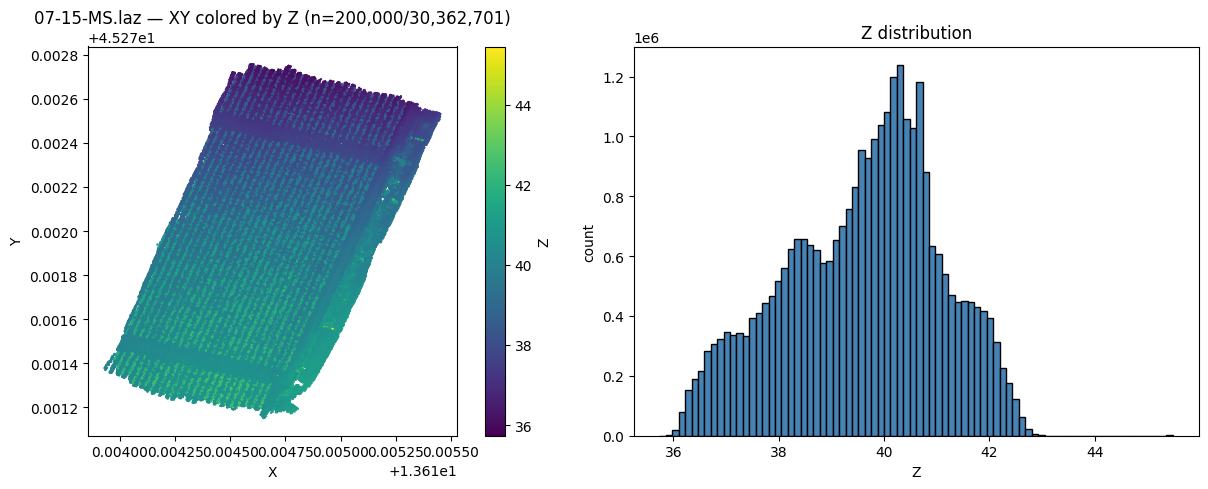

In [16]:
df_ms = inspect(FILES[0])

## 2025-07-15-IR.laz (infrared)

File:           2025-07-15-IR.laz  (80.5 MB)
Point count:    11,165,589
Point format:   2  (LAS 1.2)
Scales:         [1.e-08 1.e-08 1.e-03]
Offsets:        [13.61 45.27 40.  ]
Mins:           [13.61398445 45.27121819 47.655     ]
Maxs:           [13.61534935 45.27269176 56.347     ]
CRS:            EPSG:4326
Dimensions (22): ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'red', 'green', 'blue', 'confidence', 'normal x', 'normal y', 'normal z']

XYZ stats:
                  X             Y             Z
count  1.116559e+07  1.116559e+07  1.116559e+07
mean   1.361500e+01  4.527200e+01  5.060400e+01
std    0.000000e+00  0.000000e+00  7.190000e-01
min    1.361400e+01  4.527100e+01  4.765500e+01
25%    1.361400e+01  4.527200e+01  5.007800e+01
50%    1.361500e+01  4.527200e+01  5.052600e+01
75%    1.361500e+01  4.527200e+

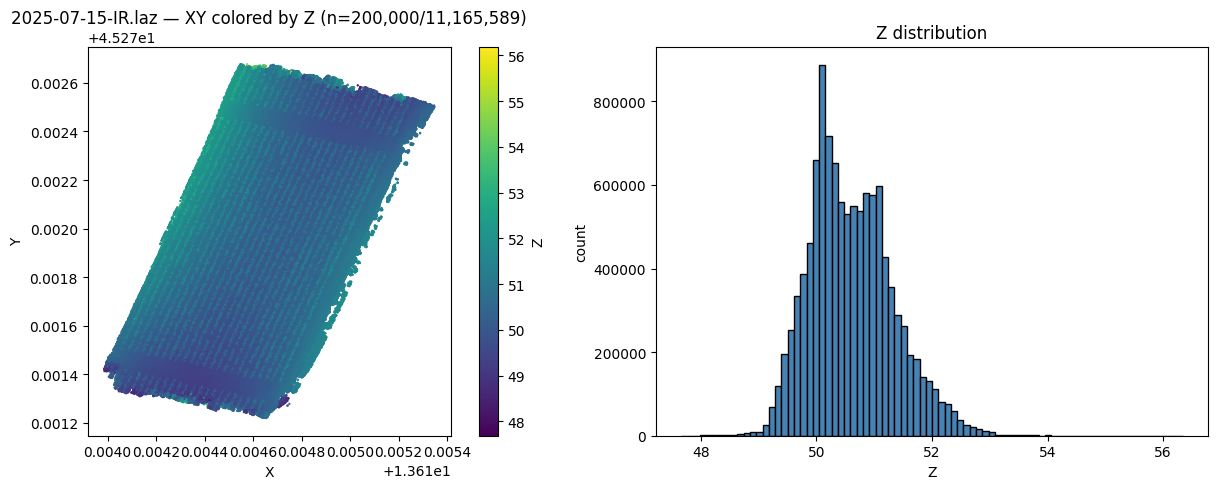

In [17]:
df_ir = inspect(FILES[1])

## 07-15-LIDAR.laz

File:           4VOLCALC.las  (0.9 MB)
Point count:    28,456
Point format:   3  (LAS 1.2)
Scales:         [0.01 0.01 0.01]
Offsets:        [2.73518e+05 5.01868e+06 3.81000e+01]
Mins:           [2.73517880e+05 5.01868222e+06 3.80999985e+01]
Maxs:           [2.73523620e+05 5.01869434e+06 4.00900002e+01]
CRS:            None
Dimensions (19): ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue']

XYZ stats:
                X            Y          Z
count   28456.000    28456.000  28456.000
mean   273521.229  5018687.799     39.121
std         0.975        2.837      0.350
min    273517.880  5018682.220     38.100
25%    273520.460  5018685.380     38.860
50%    273521.160  5018687.790     39.190
75%    273522.020  5018690.190     39.390
max    273523.620  5018694.340     40.090

Head:
     

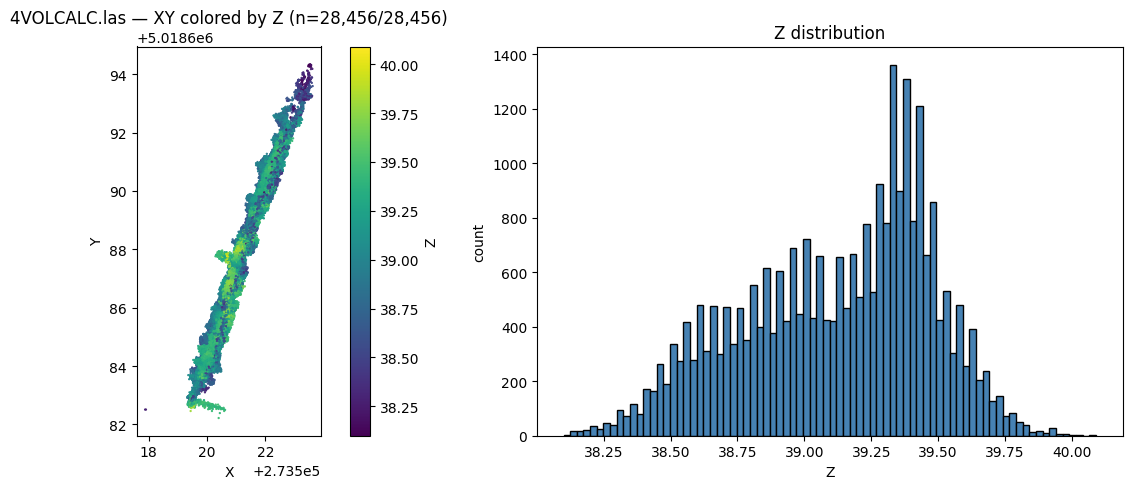

In [18]:
df_lidar = inspect(FILES[2])

## Side-by-side summary

Compact comparison of point counts, extents and dimensions.

In [19]:
rows = []
for p in FILES:
    if not p.exists():
        continue
    las = laspy.read(str(p))
    dims = list(las.point_format.dimension_names)
    rows.append({
        'file': p.name,
        'points': las.header.point_count,
        'x_range': round(las.header.maxs[0] - las.header.mins[0], 2),
        'y_range': round(las.header.maxs[1] - las.header.mins[1], 2),
        'z_range': round(las.header.maxs[2] - las.header.mins[2], 2),
        'pt_format': las.header.point_format.id,
        'n_dims': len(dims),
    })
summary_df = pd.DataFrame(rows)
summary_df

,file,points,x_range,y_range,z_range,pt_format,n_dims
0,07-15-MS.laz,30362701,0.00,0.00,9.75,8,26
1,2025-07-15-IR.laz,11165589,0.00,0.00,8.69,2,22
2,4VOLCALC.las,28456,5.74,12.12,1.99,3,19


---

# Professional analysis for academic reporting

The remainder of this notebook produces publication-ready descriptive statistics, distributions, density maps, vertical profiles and cross-sensor comparisons of the three point clouds. Every figure is suitable for inclusion in a thesis chapter on UAV multispectral / LiDAR data acquisition for precision viticulture.

## 1. Per-attribute descriptive statistics with example values

For every dimension stored in each LAS file we report dtype, count of unique values, min/max/mean/std and 5 example values. This is the table to cite when documenting the *content* of the data products in the methodology chapter.

In [20]:
def attribute_table(df: pd.DataFrame, name: str, sample_size: int = 5) -> pd.DataFrame:
    rng = np.random.default_rng(0)
    rows = []
    for col in df.columns:
        s = df[col]
        try:
            stats = {
                'attribute': col,
                'dtype': str(s.dtype),
                'n_unique': int(s.nunique()) if s.dtype != object else None,
                'min': float(np.min(s)) if np.issubdtype(s.dtype, np.number) else None,
                'max': float(np.max(s)) if np.issubdtype(s.dtype, np.number) else None,
                'mean': float(np.mean(s)) if np.issubdtype(s.dtype, np.number) else None,
                'std': float(np.std(s)) if np.issubdtype(s.dtype, np.number) else None,
            }
        except Exception:
            stats = {'attribute': col, 'dtype': str(s.dtype)}
        idx = rng.choice(len(s), min(sample_size, len(s)), replace=False)
        stats['examples'] = list(np.round(s.iloc[idx].to_numpy(), 4)) if np.issubdtype(s.dtype, np.number) else list(s.iloc[idx])
        rows.append(stats)
    out = pd.DataFrame(rows)
    print(f'\n=== Attribute table: {name} ({len(df):,} pts, {len(df.columns)} dims) ===')
    return out

attr_ms = attribute_table(df_ms, '07-15-MS.laz')
attr_ms.round(3)


=== Attribute table: 07-15-MS.laz (30,362,701 pts, 26 dims) ===


,attribute,dtype,n_unique,min,max,mean,std,examples
0,X,float64,152037,13.614,13.615,13.615,0.000,"[13.6143, 13.6149, 13.6146, 13.6149, 13.6144]"
1,Y,float64,160512,45.271,45.273,45.272,0.000,"[45.2712, 45.2716, 45.2718, 45.2716, 45.272]"
2,Z,float64,8577,35.734,45.485,39.597,1.463,"[41.413, 42.656, 37.21, 40.569, 39.086]"
3,intensity,uint16,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
4,return_number,uint8,1,1.000,1.000,1.000,0.000,"[1, 1, 1, 1, 1]"
5,number_of_returns,uint8,1,1.000,1.000,1.000,0.000,"[1, 1, 1, 1, 1]"
6,synthetic,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
7,key_point,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
8,withheld,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
9,overlap,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"


In [21]:
attr_ir = attribute_table(df_ir, '2025-07-15-IR.laz')
attr_ir.round(3)


=== Attribute table: 2025-07-15-IR.laz (11,165,589 pts, 22 dims) ===


,attribute,dtype,n_unique,min,max,mean,std,examples
0,X,float64,135648,13.614,13.615,13.615,0.000,"[13.6147, 13.6146, 13.6145, 13.6145, 13.6145]"
1,Y,float64,145718,45.271,45.273,45.272,0.000,"[45.2715, 45.2721, 45.2715, 45.2715, 45.2719]"
2,Z,float64,7015,47.655,56.347,50.604,0.719,"[49.958, 50.315, 51.056, 49.765, 51.739]"
3,intensity,uint16,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
4,return_number,uint8,1,1.000,1.000,1.000,0.000,"[1, 1, 1, 1, 1]"
5,number_of_returns,uint8,1,1.000,1.000,1.000,0.000,"[1, 1, 1, 1, 1]"
6,scan_direction_flag,uint8,1,1.000,1.000,1.000,0.000,"[1, 1, 1, 1, 1]"
7,edge_of_flight_line,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
8,classification,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
9,synthetic,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"


In [22]:
attr_lidar = attribute_table(df_lidar, '07-15-LIDAR.laz')
attr_lidar.round(3)


=== Attribute table: 07-15-LIDAR.laz (28,456 pts, 19 dims) ===


,attribute,dtype,n_unique,min,max,mean,std,examples
0,X,float64,432,273517.880,273523.620,273521.229,0.975,"[273522.57, 273522.95, 273521.52, 273523.13, 2..."
1,Y,float64,1165,5018682.220,5018694.340,5018687.799,2.837,"[5018690.59, 5018690.27, 5018689.33, 5018687.5..."
2,Z,float64,195,38.100,40.090,39.121,0.350,"[39.33, 38.85, 38.89, 39.14, 39.1]"
3,intensity,uint16,52,256.000,14592.000,4595.594,2124.028,"[5120, 5888, 4608, 4608, 768]"
4,return_number,uint8,2,1.000,2.000,1.001,0.035,"[1, 1, 1, 1, 1]"
5,number_of_returns,uint8,2,1.000,2.000,1.083,0.277,"[2, 1, 1, 1, 1]"
6,scan_direction_flag,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
7,edge_of_flight_line,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"
8,classification,uint8,1,1.000,1.000,1.000,0.000,"[1, 1, 1, 1, 1]"
9,synthetic,uint8,1,0.000,0.000,0.000,0.000,"[0, 0, 0, 0, 0]"


## 2. LAS-standard attribute distributions (intensity, returns, classification)

Histograms of `intensity`, `return_number`, `number_of_returns` and `classification` describe the radiometric and geometric quality of the acquisition. For LiDAR files the multi-return distribution is particularly relevant (canopy penetration), while for photogrammetric MS/IR products typically only the first return is populated.

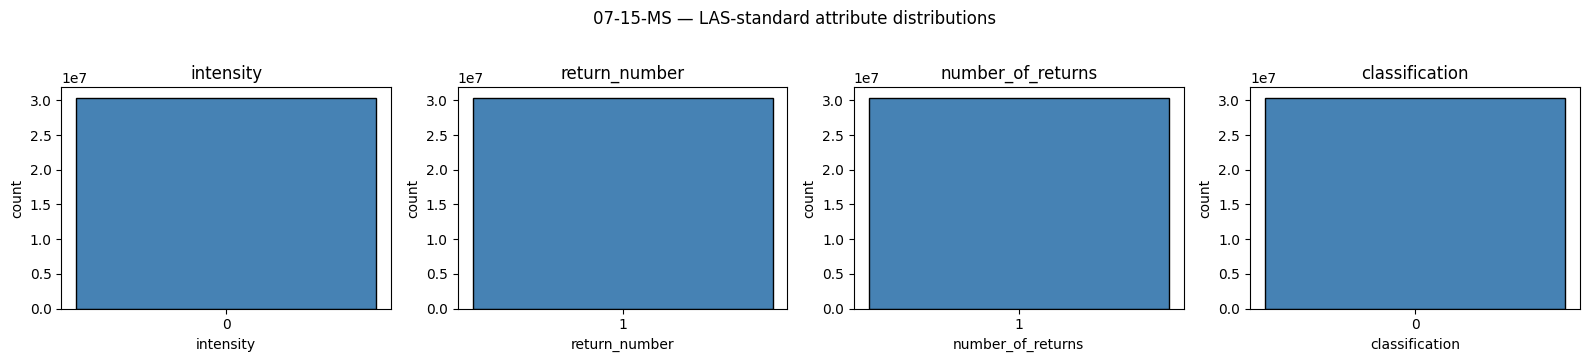

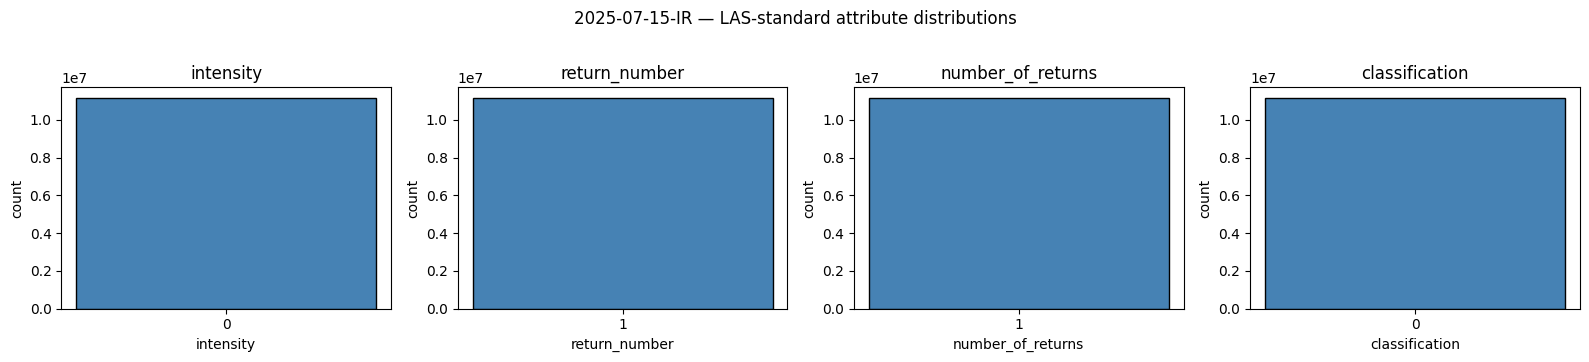

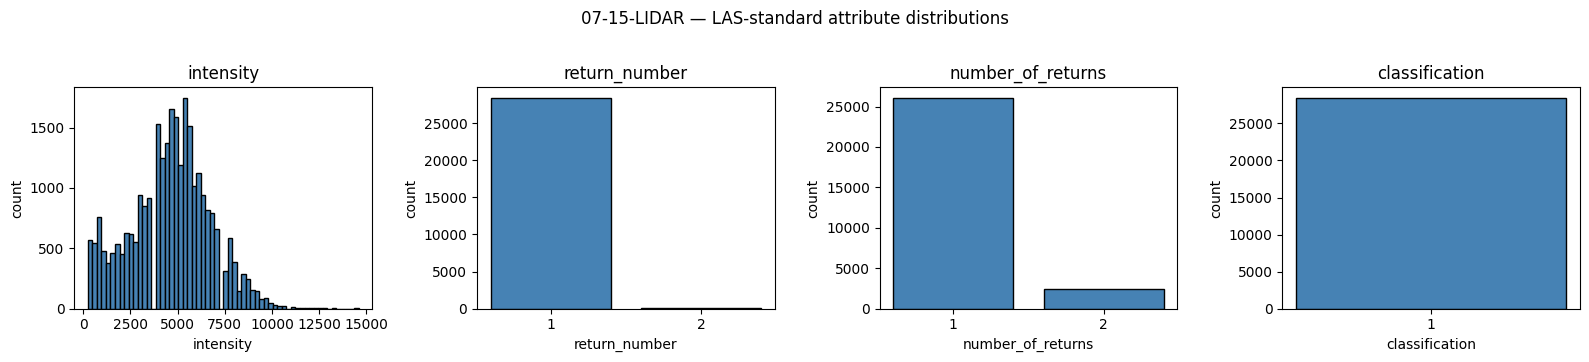

In [23]:
def plot_las_standard(df: pd.DataFrame, name: str) -> None:
    candidates = ['intensity', 'return_number', 'number_of_returns', 'classification']
    present = [c for c in candidates if c in df.columns]
    if not present:
        print(f'{name}: no LAS-standard fields present')
        return
    fig, axes = plt.subplots(1, len(present), figsize=(4 * len(present), 3.5))
    if len(present) == 1:
        axes = [axes]
    for ax, col in zip(axes, present):
        s = df[col]
        if s.nunique() <= 16:
            vc = s.value_counts().sort_index()
            ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black')
            ax.set_xlabel(col)
            ax.set_ylabel('count')
        else:
            ax.hist(s, bins=60, color='steelblue', edgecolor='black')
            ax.set_xlabel(col)
            ax.set_ylabel('count')
        ax.set_title(f'{col}')
    fig.suptitle(f'{name} — LAS-standard attribute distributions', y=1.02)
    plt.tight_layout()
    plt.show()

for nm, df in [('07-15-MS', df_ms), ('2025-07-15-IR', df_ir), ('07-15-LIDAR', df_lidar)]:
    plot_las_standard(df, nm)

## 3. Spectral / colour bands and NDVI

Multispectral and infrared products typically expose `red`, `green`, `blue` and `nir` (sometimes named `infrared`, `Reflectance`, or stored in `Red`/`Green`/`Blue` LAS fields). The cell below auto-discovers the band columns and plots:

- per-band reflectance histograms,
- 2D NDVI map: `NDVI = (NIR - Red) / (NIR + Red)`, computed only when both `red` and a NIR-equivalent band are available,
- NDVI distribution (vegetation vigour signature).

NDVI > 0.3 is generally vegetated; > 0.6 is dense canopy. This is the figure that should anchor the *vegetation index* section of the thesis.


07-15-MS: detected bands -> {'red': 'red', 'green': 'green', 'blue': 'blue', 'nir': 'nir'}


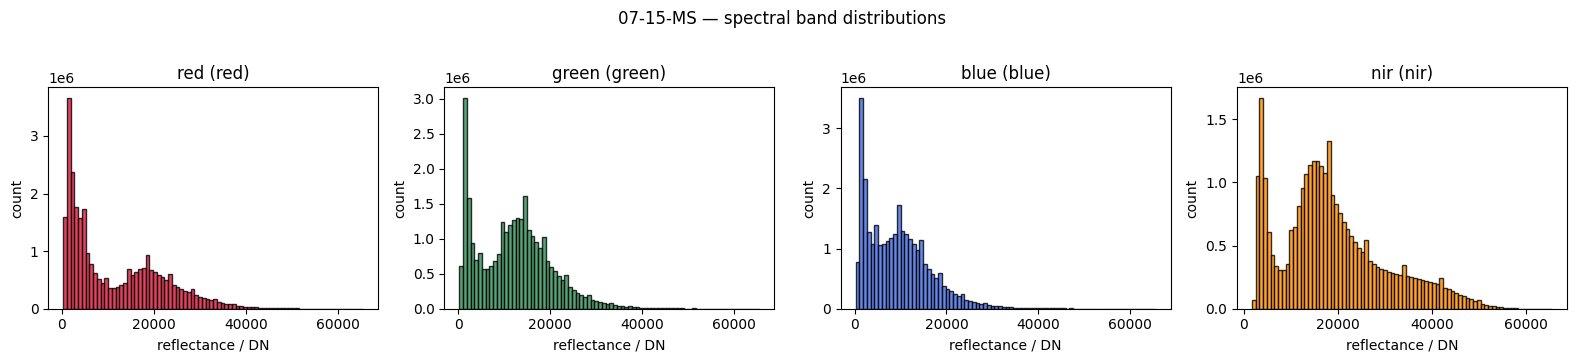

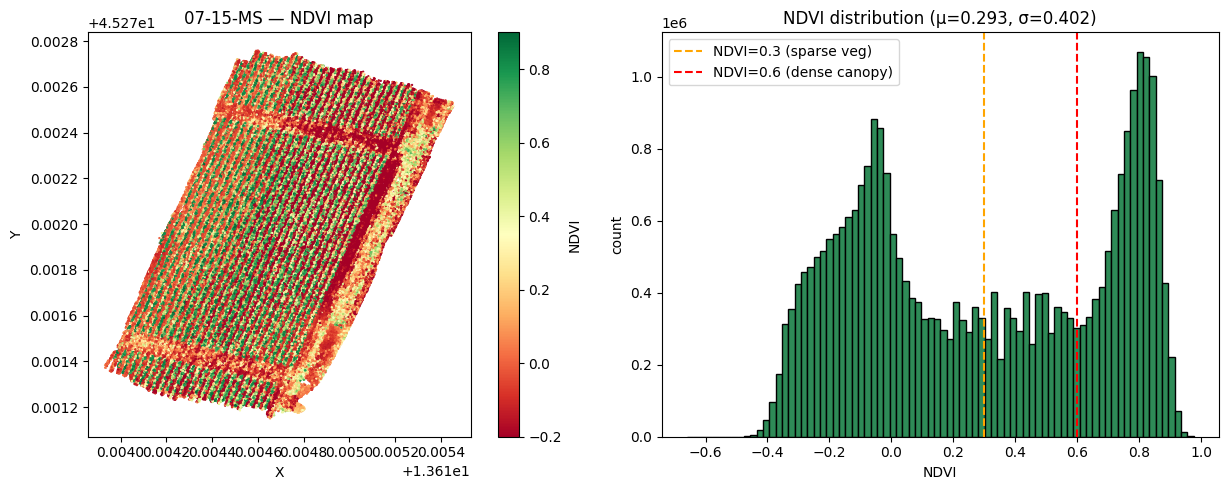


2025-07-15-IR: detected bands -> {'red': 'red', 'green': 'green', 'blue': 'blue'}


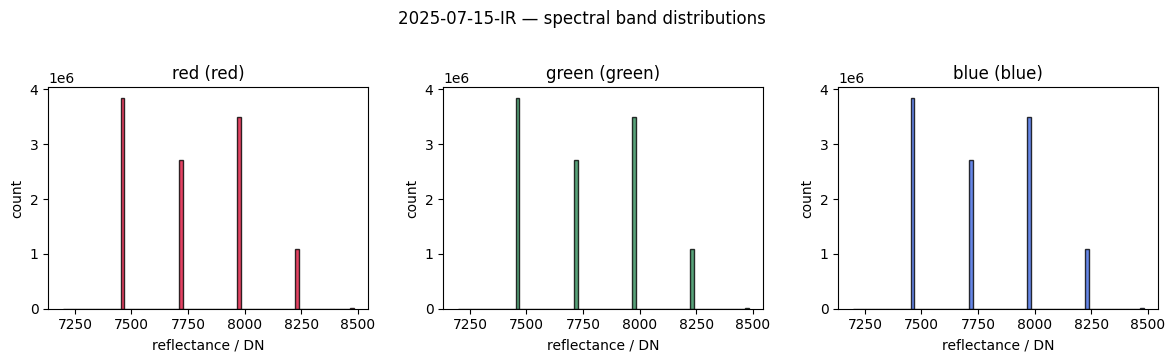

  NDVI not computable (need both red and nir bands)

07-15-LIDAR: detected bands -> {'red': 'red', 'green': 'green', 'blue': 'blue'}


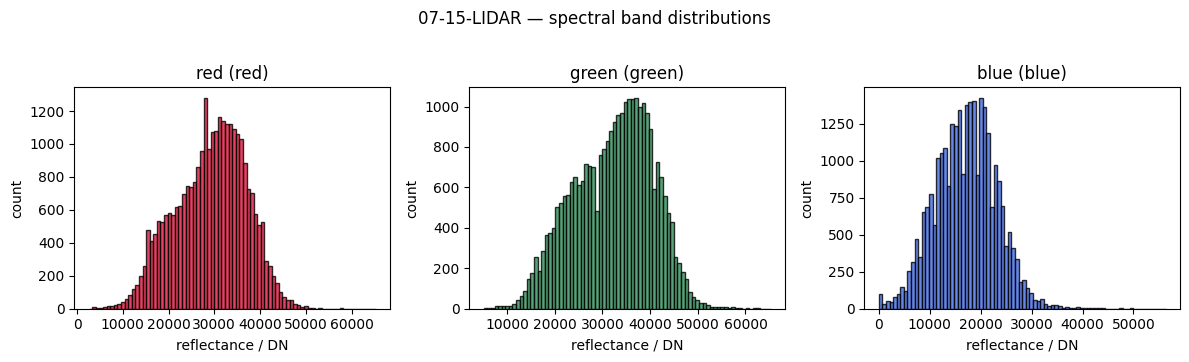

  NDVI not computable (need both red and nir bands)


In [24]:
BAND_ALIASES = {
    'red': ['red', 'Red', 'R'],
    'green': ['green', 'Green', 'G'],
    'blue': ['blue', 'Blue', 'B'],
    'nir': ['nir', 'NIR', 'infrared', 'Infrared', 'IR', 'NearInfrared', 'near_infrared'],
}

def find_bands(df: pd.DataFrame) -> dict:
    found = {}
    for canonical, aliases in BAND_ALIASES.items():
        for a in aliases:
            if a in df.columns:
                found[canonical] = a
                break
    return found


def spectral_report(df: pd.DataFrame, name: str) -> None:
    bands = find_bands(df)
    print(f'\n{name}: detected bands -> {bands}')
    if not bands:
        print('  (no recognised spectral band columns)')
        return

    # subsample for plotting
    n = len(df)
    if n > MAX_PLOT_POINTS:
        idx = np.random.default_rng(1).choice(n, MAX_PLOT_POINTS, replace=False)
        d = df.iloc[idx]
    else:
        d = df

    # Per-band histograms
    fig, axes = plt.subplots(1, len(bands), figsize=(4 * len(bands), 3.5))
    if len(bands) == 1:
        axes = [axes]
    colors = {'red': 'crimson', 'green': 'seagreen', 'blue': 'royalblue', 'nir': 'darkorange'}
    for ax, (canonical, col) in zip(axes, bands.items()):
        ax.hist(df[col], bins=80, color=colors.get(canonical, 'gray'), edgecolor='black', alpha=0.8)
        ax.set_title(f'{canonical} ({col})')
        ax.set_xlabel('reflectance / DN')
        ax.set_ylabel('count')
    fig.suptitle(f'{name} — spectral band distributions', y=1.02)
    plt.tight_layout()
    plt.show()

    # NDVI
    if 'red' in bands and 'nir' in bands:
        red = df[bands['red']].astype(np.float64)
        nir = df[bands['nir']].astype(np.float64)
        denom = nir + red
        ndvi = np.where(denom != 0, (nir - red) / denom, np.nan)
        ndvi = np.clip(ndvi, -1, 1)

        d_ndvi = ndvi[idx] if n > MAX_PLOT_POINTS else ndvi

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        sc = axes[0].scatter(d['X'], d['Y'], c=d_ndvi, s=0.4, cmap='RdYlGn', vmin=-0.2, vmax=0.9)
        axes[0].set_aspect('equal')
        axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
        axes[0].set_title(f'{name} — NDVI map')
        fig.colorbar(sc, ax=axes[0], label='NDVI')

        valid = ndvi[np.isfinite(ndvi)]
        axes[1].hist(valid, bins=80, color='seagreen', edgecolor='black')
        axes[1].axvline(0.3, color='orange', ls='--', label='NDVI=0.3 (sparse veg)')
        axes[1].axvline(0.6, color='red', ls='--', label='NDVI=0.6 (dense canopy)')
        axes[1].set_xlabel('NDVI'); axes[1].set_ylabel('count')
        axes[1].set_title(f'NDVI distribution (μ={valid.mean():.3f}, σ={valid.std():.3f})')
        axes[1].legend()
        plt.tight_layout()
        plt.show()
    else:
        print('  NDVI not computable (need both red and nir bands)')

for nm, df in [('07-15-MS', df_ms), ('2025-07-15-IR', df_ir), ('07-15-LIDAR', df_lidar)]:
    spectral_report(df, nm)

## 4. Point density (planimetric) and ground-sampling distance

Point density [pts/m²] is the most important quality metric for downstream segmentation, ground filtering and volume estimation. We compute density as a 2D histogram of XY at 0.5 m resolution and report:

- mean / median / 95th-percentile point density,
- equivalent average ground-sampling distance `GSD ≈ 1 / sqrt(density)`,
- a 2D density heatmap (this figure should appear in the *data* chapter).

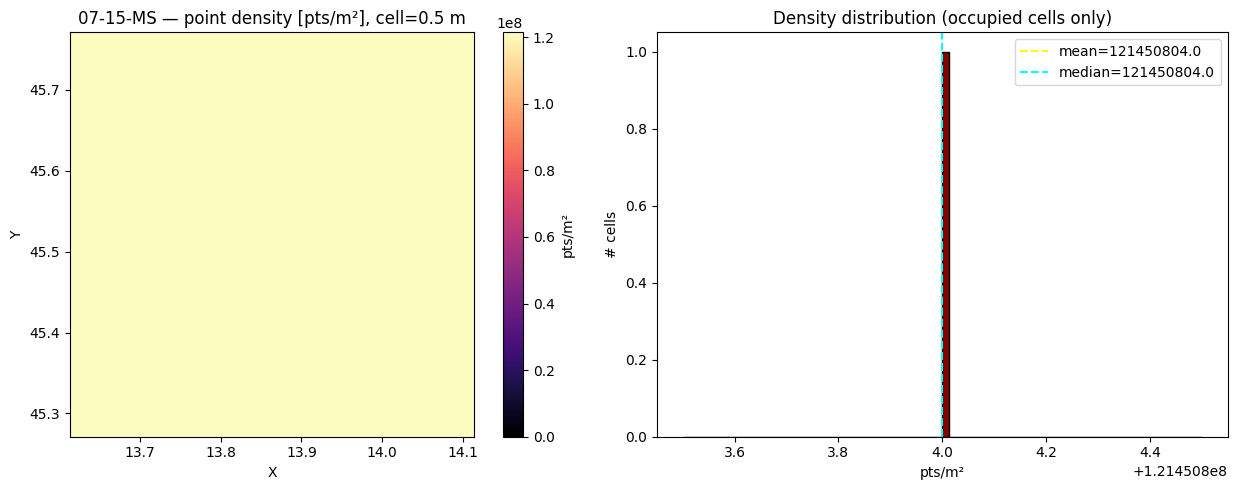

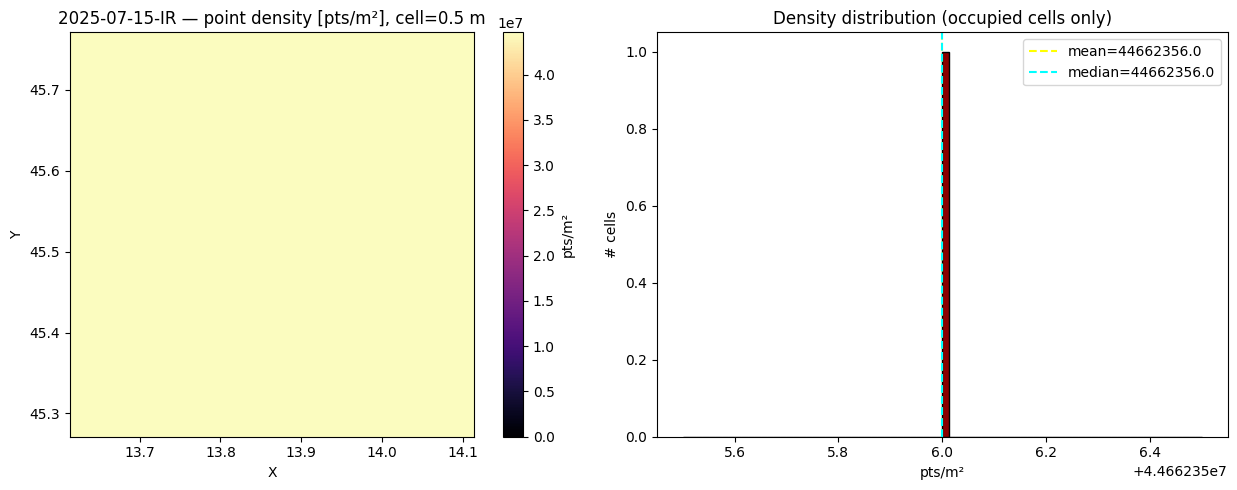

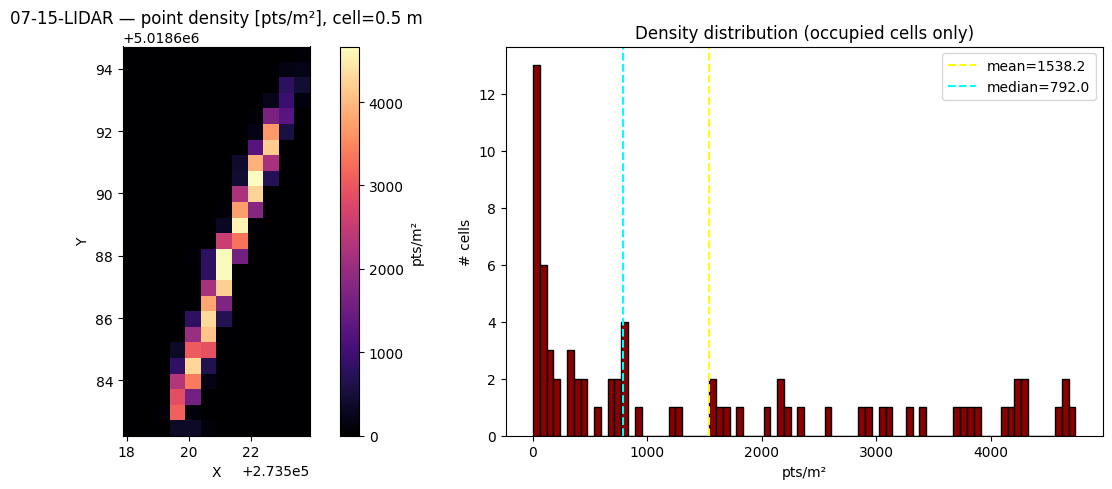

,file,cell_m,occupied_cells,mean_pts_per_m2,median_pts_per_m2,p95_pts_per_m2,avg_gsd_m,footprint_m2
0,07-15-MS,0.5,1,1.214508e+08,121450804.0,121450804.0,0.000,0.25
1,2025-07-15-IR,0.5,1,4.466236e+07,44662356.0,44662356.0,0.000,0.25
2,07-15-LIDAR,0.5,74,1.538162e+03,792.0,4402.8,0.025,18.50


In [25]:
def density_report(df: pd.DataFrame, name: str, cell: float = 0.5):
    x, y = df['X'].to_numpy(), df['Y'].to_numpy()
    x_edges = np.arange(x.min(), x.max() + cell, cell)
    y_edges = np.arange(y.min(), y.max() + cell, cell)
    H, xe, ye = np.histogram2d(x, y, bins=[x_edges, y_edges])
    cell_area = cell * cell
    density = H / cell_area
    nonempty = density[density > 0]
    stats = {
        'file': name,
        'cell_m': cell,
        'occupied_cells': int((H > 0).sum()),
        'mean_pts_per_m2': float(nonempty.mean()),
        'median_pts_per_m2': float(np.median(nonempty)),
        'p95_pts_per_m2': float(np.percentile(nonempty, 95)),
        'avg_gsd_m': float(1.0 / np.sqrt(nonempty.mean())),
        'footprint_m2': float((H > 0).sum() * cell_area),
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    im = axes[0].imshow(
        density.T, origin='lower',
        extent=[xe[0], xe[-1], ye[0], ye[-1]],
        cmap='magma', aspect='equal',
        vmin=0, vmax=np.percentile(nonempty, 99),
    )
    axes[0].set_title(f'{name} — point density [pts/m²], cell={cell} m')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
    fig.colorbar(im, ax=axes[0], label='pts/m²')

    axes[1].hist(nonempty, bins=80, color='darkred', edgecolor='black')
    axes[1].axvline(stats['mean_pts_per_m2'], color='yellow', ls='--', label=f"mean={stats['mean_pts_per_m2']:.1f}")
    axes[1].axvline(stats['median_pts_per_m2'], color='cyan', ls='--', label=f"median={stats['median_pts_per_m2']:.1f}")
    axes[1].set_xlabel('pts/m²'); axes[1].set_ylabel('# cells')
    axes[1].set_title('Density distribution (occupied cells only)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    return stats

density_stats = []
for nm, df in [('07-15-MS', df_ms), ('2025-07-15-IR', df_ir), ('07-15-LIDAR', df_lidar)]:
    density_stats.append(density_report(df, nm))
density_df = pd.DataFrame(density_stats).round(3)
density_df

## 5. Vertical structure: elevation profile and canopy height proxy

The Z-distribution after subtracting the local terrain minimum is a proxy for canopy height. We compute a *normalised elevation* `Zn = Z − Z_min(2 m cell)` and plot:

- KDE / histogram of `Zn` per dataset (canopy height distribution),
- a vertical *cross-section* (Y vs Z, slice through the median X) showing the row structure of the vineyard. The LiDAR cross-section is the strongest evidence in the thesis that LiDAR captures sub-canopy structure invisible to photogrammetry.

In [ ]:
def normalised_z(df: pd.DataFrame, cell: float = 2.0) -> np.ndarray:
    """Per-point Z minus the minimum Z within its (cell x cell) XY bin.
    Vectorised via pandas groupby-transform (robust for any number of cells)."""
    x = df['X'].to_numpy()
    y = df['Y'].to_numpy()
    z = df['Z'].to_numpy()
    ix = np.floor((x - x.min()) / cell).astype(np.int64)
    iy = np.floor((y - y.min()) / cell).astype(np.int64)
    key = ix * (iy.max() + 1) + iy
    z_min_per_pt = pd.Series(z).groupby(key).transform('min').to_numpy()
    return z - z_min_per_pt


def vertical_report(df: pd.DataFrame, name: str) -> None:
    zn = normalised_z(df)
    x = df['X'].to_numpy()
    y = df['Y'].to_numpy()
    z = df['Z'].to_numpy()
    x_med = np.median(x)
    # adapt strip width to dataset extent so small clouds still produce a slice
    x_extent = float(x.max() - x.min())
    strip_half = max(0.5, min(1.0, 0.05 * x_extent))
    mask = np.abs(x - x_med) < strip_half
    n_strip = int(mask.sum())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(zn, bins=120, color='forestgreen', edgecolor='black')
    axes[0].set_xlabel('Normalised elevation Zn [m]')
    axes[0].set_ylabel('count')
    axes[0].set_title(f'{name} — canopy-height proxy distribution')
    axes[0].axvline(np.percentile(zn, 95), color='red', ls='--', label=f'p95={np.percentile(zn,95):.2f} m')
    axes[0].legend()

    if n_strip > 0:
        idx = np.where(mask)[0]
        if len(idx) > MAX_PLOT_POINTS:
            idx = np.random.default_rng(2).choice(idx, MAX_PLOT_POINTS, replace=False)
        axes[1].scatter(y[idx], z[idx], s=0.3, c=zn[idx], cmap='viridis')
        axes[1].set_xlabel('Y'); axes[1].set_ylabel('Z')
        axes[1].set_title(f'Cross-section (X≈median, ±{strip_half:.2f} m, n={len(idx):,})')
    else:
        axes[1].text(0.5, 0.5, 'no points in strip', ha='center', va='center')
    plt.tight_layout()
    plt.show()

for nm, df in [('07-15-MS', df_ms), ('2025-07-15-IR', df_ir), ('07-15-LIDAR', df_lidar)]:
    vertical_report(df, nm)

## 6. Spatial-footprint comparison (cross-sensor co-registration check)

The MS, IR and LiDAR acquisitions cover overlapping but not identical extents (the LiDAR flight covered a different portion of the field). Plotting bounding boxes and (sub-sampled) point footprints in a single coordinate frame highlights the registration relationship — essential for the *fusion* discussion in the thesis.

In [ ]:
def subsample(df, n_target=30_000, seed=3):
    if len(df) <= n_target:
        return df
    idx = np.random.default_rng(seed).choice(len(df), n_target, replace=False)
    return df.iloc[idx]

datasets = [
    ('07-15-MS',    df_ms,    'tab:blue'),
    ('2025-07-15-IR', df_ir,  'tab:orange'),
    ('07-15-LIDAR', df_lidar, 'tab:green'),
]

fig, ax = plt.subplots(figsize=(10, 9))
for name, df, color in datasets:
    d = subsample(df)
    ax.scatter(d['X'], d['Y'], s=0.4, alpha=0.35, color=color, label=f'{name} (n={len(df):,})')
    xmin, xmax = df['X'].min(), df['X'].max()
    ymin, ymax = df['Y'].min(), df['Y'].max()
    ax.plot([xmin, xmax, xmax, xmin, xmin],
            [ymin, ymin, ymax, ymax, ymin],
            color=color, lw=2)

ax.set_aspect('equal')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Spatial footprints — MS / IR / LiDAR overlay')
ax.legend(markerscale=10, loc='best')
plt.tight_layout()
plt.show()

footprint_summary = pd.DataFrame([{
    'file': name,
    'x_min': df['X'].min(), 'x_max': df['X'].max(),
    'y_min': df['Y'].min(), 'y_max': df['Y'].max(),
    'z_min': df['Z'].min(), 'z_max': df['Z'].max(),
    'centroid_x': df['X'].mean(),
    'centroid_y': df['Y'].mean(),
} for name, df, _ in datasets]).round(2)
footprint_summary

## 7. Pairwise correlation of band / intensity / height attributes

For the multispectral and infrared datasets we compute a Spearman correlation matrix between *numeric* per-point attributes (bands, intensity, Z, normalised Z). Strong band-to-band correlations indicate redundancy; band ↔ Z correlation suggests structural illumination effects worth noting in the discussion.

In [ ]:
def correlation_matrix(df, name, sample=100_000):
    candidate_cols = [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    # drop near-constant
    keep = [c for c in candidate_cols if df[c].nunique() > 1]
    if len(keep) < 2:
        print(f'{name}: not enough numeric columns for correlation')
        return
    n = len(df)
    if n > sample:
        idx = np.random.default_rng(4).choice(n, sample, replace=False)
        sub = df.iloc[idx][keep]
    else:
        sub = df[keep]
    corr = sub.corr(method='spearman')

    fig, ax = plt.subplots(figsize=(0.55 * len(keep) + 3, 0.55 * len(keep) + 2))
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(keep))); ax.set_xticklabels(keep, rotation=45, ha='right')
    ax.set_yticks(range(len(keep))); ax.set_yticklabels(keep)
    for i in range(len(keep)):
        for j in range(len(keep)):
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                    color='white' if abs(corr.values[i,j]) > 0.5 else 'black', fontsize=7)
    ax.set_title(f'{name} — Spearman correlation (n={len(sub):,})')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

for nm, df in [('07-15-MS', df_ms), ('2025-07-15-IR', df_ir), ('07-15-LIDAR', df_lidar)]:
    correlation_matrix(df, nm)

## 8. Cross-sensor consolidated metrics

A single comparison table that consolidates point count, footprint, density, vertical extent and detected dimensions for the three sensors. This is the *Table 1* of the data chapter.

In [ ]:
consolidated = []
for (nm, df), dens in zip(
    [('07-15-MS', df_ms), ('2025-07-15-IR', df_ir), ('07-15-LIDAR', df_lidar)],
    density_stats,
):
    bands = find_bands(df)
    consolidated.append({
        'sensor': nm,
        'points': len(df),
        'footprint_m2': dens['footprint_m2'],
        'mean_density_pts_m2': dens['mean_pts_per_m2'],
        'avg_gsd_m': dens['avg_gsd_m'],
        'z_range_m': round(df['Z'].max() - df['Z'].min(), 2),
        'z_p95_normalised_m': round(np.percentile(normalised_z(df), 95), 2),
        'has_red': 'red' in bands,
        'has_nir': 'nir' in bands,
        'n_dims': df.shape[1],
    })
consolidated_df = pd.DataFrame(consolidated).round(3)
consolidated_df

---

# Report — figures to include in the thesis

This notebook contains the descriptive analysis of the three input point clouds (MS, IR, LiDAR) used in the master-thesis pipeline. The narrative below maps every figure / table generated above to the section of the thesis where it should appear and to the argument it supports.

## Recommended figure set (in order of appearance)

| # | Figure / Table | Notebook section | Thesis chapter | Caption / argument |
|---|---|---|---|---|
| **F1** | LAS header + dimension list (printed log) | §1 Per-attribute table | *Data — acquisition* | Documents that each LAS file conforms to point format X with N dimensions; cite scales/offsets/CRS for reproducibility. |
| **T1** | Per-attribute descriptive table (`attr_ms`, `attr_ir`, `attr_lidar`) | §1 | *Data — content* | Single table per sensor listing dtype, range, mean, std and 5 example values for every dimension. Justifies which dimensions are usable downstream. |
| **F2** | LAS-standard distributions (intensity, return number, classification) | §2 | *Data — quality* | Shows that LiDAR has multi-return information (canopy penetration), while MS/IR are single-return photogrammetric products. |
| **F3** | Spectral-band histograms (R, G, B, NIR) | §3 | *Methodology — vegetation indices* | Demonstrates the dynamic range of each band and the absence of saturation, prerequisite for NDVI. |
| **F4** | NDVI map + NDVI histogram | §3 | *Results — vegetation vigour* | The flagship figure linking sensor data to viticultural interpretation; report mean ± std and the fraction above the 0.6 dense-canopy threshold. |
| **F5** | Point-density heatmap + density distribution | §4 | *Data — quality / methodology — sampling* | Justifies voxel size, ground-filtering parameters and downstream resolution choices. |
| **F6** | Canopy-height proxy histogram + Y–Z cross-section | §5 | *Results — canopy structure* | Cross-section through the median X exposes vine-row architecture; the contrast between LiDAR (thick canopy returns + ground) and MS/IR (only canopy surface) is the core *why-LiDAR* argument. |
| **F7** | Spatial-footprint overlay (XY) | §6 | *Data — co-registration* | Shows that the LiDAR flight covers a different sub-area; motivates why fusion is performed only on the spatial intersection. |
| **F8** | Spearman correlation heatmaps | §7 | *Discussion — feature redundancy* | Quantifies band-to-band redundancy and any spurious correlation between intensity / Z, useful when justifying feature selection. |
| **T2** | Consolidated cross-sensor metrics (`consolidated_df`) | §8 | *Data — Table 1* | One-table summary the reader returns to throughout the thesis. |

## How to use these figures in writing

1. **Acquisition / data chapter** — open with **T1 + T2** (objective description) and **F1 / F7** (where the data was captured). Together they describe *what we have and where it is*.
2. **Quality / preprocessing chapter** — use **F2** to argue why ground filtering and clustering parameters were chosen, and **F5** to defend the resolution of every raster / voxel grid downstream.
3. **Vegetation-indices chapter** — anchor on **F3 → F4**; report NDVI mean ± std and the fraction of points exceeding 0.6 (dense canopy) as a quantitative outcome.
4. **Canopy-structure / volume chapter** — lead with **F6** (cross-section); the LiDAR strip should clearly show row tops + ground returns, while MS/IR strips show only the upper envelope. This is the empirical motivation for using LiDAR-derived volume as ground truth.
5. **Discussion** — cite **F8** when explaining why only a subset of bands enters the index calculation, and refer back to **F7** when bounding the validity of any cross-sensor fusion claim.

## Reproducibility note

All figures are generated from a single notebook (`inspect_laz_files.ipynb`) directly from the canonical `datasource/` files; no intermediate exports are required. Random-seed values are fixed (`rng = np.random.default_rng(0..4)`) so subsamples and example values are deterministic. When citing in the thesis, mention the LAS specification version and software stack: `laspy ≥ 2.5`, `numpy`, `pandas`, `matplotlib`.